In [23]:
import os
import pandas as pd
from typing import Optional

In [24]:
def combine_all_years_to_df(data_dir, years=range(2016, 2024)):
    '''
    Function to combine data for multiple years into a single DataFrame.
    
    Args: 
        - years (list of int): List of years to combine.
    Returns:
        - combined_df (pd.DataFrame): A DataFrame containing all combined data for the given years.
    '''
    combined = []
    for year in years:
        path = os.path.join(data_dir, f"playbyplay-{str(year)}.json")
        df = pd.read_json(path)
        combined.append(df)
    
    combined_df = pd.concat(combined, ignore_index=True)
    return combined_df

In [25]:
df = combine_all_years_to_df('data')
df

,id,season,gameType,limitedScoring,gameDate,venue,venueLocation,startTimeUTC,easternUTCOffset,venueUTCOffset,...,otInUse,clock,displayPeriod,maxPeriods,gameOutcome,plays,rosterSpots,regPeriods,summary,specialEvent
0,2016020001,20162017,2,False,2016-10-12,{'default': 'Canadian Tire Centre'},{'default': 'Ottawa'},2016-10-12T23:00:00Z,-04:00,-04:00,...,True,"{'timeRemaining': '00:00', 'secondsRemaining':...",1,5.0,"{'lastPeriodType': 'OT', 'otPeriods': 1}","[{'eventId': 5, 'periodDescriptor': {'number':...","[{'teamId': 9, 'playerId': 8467493, 'firstName...",3,{},NaN
1,2016020002,20162017,2,False,2016-10-12,{'default': 'United Center'},{'default': 'Chicago'},2016-10-13T00:00:00Z,-04:00,-05:00,...,True,"{'timeRemaining': '00:00', 'secondsRemaining':...",1,5.0,{'lastPeriodType': 'REG'},"[{'eventId': 5, 'periodDescriptor': {'number':...","[{'teamId': 16, 'playerId': 8466148, 'firstNam...",3,{},NaN
2,2016020003,20162017,2,False,2016-10-12,{'default': 'Rogers Place'},{'default': 'Edmonton'},2016-10-13T02:00:00Z,-04:00,-06:00,...,True,"{'timeRemaining': '00:00', 'secondsRemaining':...",1,5.0,{'lastPeriodType': 'REG'},"[{'eventId': 51, 'periodDescriptor': {'number'...","[{'teamId': 20, 'playerId': 8468674, 'firstNam...",3,{},NaN
3,2016020004,20162017,2,False,2016-10-12,{'default': 'SAP Center at San Jose'},{'default': 'San Jose'},2016-10-13T02:30:00Z,-04:00,-07:00,...,True,"{'timeRemaining': '00:00', 'secondsRemaining':...",1,5.0,{'lastPeriodType': 'REG'},"[{'eventId': 5, 'periodDescriptor': {'number':...","[{'teamId': 28, 'playerId': 8466138, 'firstNam...",3,{},NaN
4,2016020005,20162017,2,False,2016-10-13,{'default': 'KeyBank Center'},{'default': 'Buffalo'},2016-10-13T23:00:00Z,-04:00,-04:00,...,True,"{'timeRemaining': '00:00', 'secondsRemaining':...",1,5.0,{'lastPeriodType': 'REG'},"[{'eventId': 51, 'periodDescriptor': {'number'...","[{'teamId': 7, 'playerId': 8467407, 'firstName...",3,{},NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10378,2023030413,20232024,3,False,2024-06-13,{'default': 'Rogers Place'},{'default': 'Edmonton'},2024-06-14T00:00:00Z,-04:00,-06:00,...,True,"{'timeRemaining': '00:00', 'secondsRemaining':...",1,NaN,{'lastPeriodType': 'REG'},"[{'eventId': 102, 'periodDescriptor': {'number...","[{'teamId': 22, 'playerId': 8470621, 'firstNam...",3,{},NaN
10379,2023030414,20232024,3,False,2024-06-15,{'default': 'Rogers Place'},{'default': 'Edmonton'},2024-06-16T00:00:00Z,-04:00,-06:00,...,True,"{'timeRemaining': '00:00', 'secondsRemaining':...",1,NaN,{'lastPeriodType': 'REG'},"[{'eventId': 52, 'periodDescriptor': {'number'...","[{'teamId': 22, 'playerId': 8470621, 'firstNam...",3,{},NaN
10380,2023030415,20232024,3,False,2024-06-18,{'default': 'Amerant Bank Arena'},{'default': 'Sunrise'},2024-06-19T00:00:00Z,-04:00,-04:00,...,True,"{'timeRemaining': '00:00', 'secondsRemaining':...",1,NaN,{'lastPeriodType': 'REG'},"[{'eventId': 102, 'periodDescriptor': {'number...","[{'teamId': 22, 'playerId': 8470621, 'firstNam...",3,{},NaN
10381,2023030416,20232024,3,False,2024-06-21,{'default': 'Rogers Place'},{'default': 'Edmonton'},2024-06-22T00:00:00Z,-04:00,-06:00,...,True,"{'timeRemaining': '00:00', 'secondsRemaining':...",1,NaN,{'lastPeriodType': 'REG'},"[{'eventId': 52, 'periodDescriptor': {'number'...","[{'teamId': 22, 'playerId': 8470621, 'firstNam...",3,{},NaN


In [26]:
def process_to_dataframe(df: pd.DataFrame) -> Optional[pd.DataFrame]:
    """
    Transforms a raw game-level DataFrame into a clean one.

    This function iterates through each game in the input DataFrame
    to contain nested JSON-like data for plays and rosters. 
    For each game the operations are:
        1.  Filters for 'shot-on-goal' and 'goal' events only.
        2.  Creates lookup maps to translate player and team IDs into human-readable names.
        3.  Infers the attacking direction ('left' or 'right') for each team in each period.
        4.  Decodes the 'situationCode' to derive on-ice strength (e.g., 'Power Play').
        5.  Derives new features such as 'emptyNet' and 'attackingDirection'.
        6.  Renames and reorders columns to create a clean, analysis-ready format.
    

    Args:
        df (pd.DataFrame): A DataFrame where each row represents a single game as a json format
            (Generated by DataFetcher class)

    Returns:
        pd.DataFrame: A clean DataFrame where each row is a single shot or goal
                      event
    """
    
    all_plays = []
    for _, row in df.iterrows(): 
        
        if "plays" not in row or not isinstance(row["plays"], list) or len(row["plays"]) == 0:
            continue
        
        home_team_id = row['homeTeam']['id']
        away_team_id = row['awayTeam']['id']

        roster = pd.json_normalize(row["rosterSpots"])
        player_lookup = (roster.assign(full_name=roster["firstName.default"] + " " + roster["lastName.default"])
                               .set_index("playerId")["full_name"]
                               .to_dict())        
        team_abbrev_lookup = {row["homeTeam"]["id"]: row["homeTeam"]["abbrev"],
                              row["awayTeam"]["id"]: row["awayTeam"]["abbrev"]}
        
        direction_cache = {}
        plays_raw = pd.json_normalize(row['plays'])
        
        shot_types = ['shot-on-goal', 'missed-shot', 'blocked-shot', 'goal']
        if 'details.xCoord' in plays_raw.columns:
            shot_plays = plays_raw[plays_raw['typeDescKey'].isin(shot_types)].copy()
            
            if not shot_plays.empty and 'details.eventOwnerTeamId' in shot_plays.columns:
                shot_plays['teamId'] = shot_plays['details.eventOwnerTeamId']
                shot_plays['period'] = shot_plays['periodDescriptor.number']
                
                for (team_id, period), subset in shot_plays.groupby(['teamId', 'period']):
                    subset = subset.dropna(subset=['details.xCoord'])
                    if not subset.empty:
                        mean_x = subset['details.xCoord'].mean()
                        
                        direction = 'left' if mean_x < 0 else 'right'
                        direction_cache.setdefault(period, {})[team_id] = direction
        
        plays = pd.json_normalize(row['plays'])
        plays = plays[plays['typeDescKey'].isin(['shot-on-goal', 'goal'])]
                
        keep_cols = ['timeInPeriod', 
                     'periodDescriptor.number',
                     'details.eventOwnerTeamId', 
                     'typeDescKey', 
                     'details.xCoord', 
                     'details.yCoord', 
                     'details.shootingPlayerId', 
                     'details.goalieInNetId', 
                     'details.shotType', 
                     'situationCode']
        plays = plays[keep_cols]
        
        plays['gameId'] = row['id']
        plays['season'] = plays['gameId'].astype(str).str[:4].astype(int)
        plays["shooterName"] = plays["details.shootingPlayerId"].map(player_lookup).fillna("Unknown")
        plays["goalieName"]  = plays["details.goalieInNetId"].map(player_lookup).fillna("Unknown")
        plays["teamName"] = plays["details.eventOwnerTeamId"].map(team_abbrev_lookup)

        situation = plays["situationCode"].astype(str)
        plays["away_goalie"]   = situation.str[0] == "1"
        plays["away_skaters"]  = situation.str[1].astype(int)
        plays["home_skaters"]  = situation.str[2].astype(int)
        plays["home_goalie"]   = situation.str[3] == "1"
        
        
        def get_team_side(team_id):
            if team_id == home_team_id:
                return "home"
            elif team_id == away_team_id:
                return "away"

            
        def is_empty_net(p):
            
            shooter_team = p["details.eventOwnerTeamId"]
            home_goalie = p.get("home_goalie", True)
            away_goalie = p.get("away_goalie", True)

            if shooter_team == home_team_id:
                return not away_goalie  
            elif shooter_team == away_team_id:
                return not home_goalie 
            return None


        def play_strength(p):
            
            home_skaters = p.get("home_skaters", 5)
            away_skaters = p.get("away_skaters", 5)
            shooter_team = p["details.eventOwnerTeamId"]

            if home_skaters == away_skaters:
                return f"Even ({home_skaters}v{away_skaters})"
            elif shooter_team == home_team_id:
                if home_skaters > away_skaters:
                    return f"Power Play ({home_skaters}v{away_skaters})"
                else:
                    return f"Short Handed ({home_skaters}v{away_skaters})"
            elif shooter_team == away_team_id:
                if away_skaters > home_skaters:
                    return f"Power Play ({home_skaters}v{away_skaters})"
                else:
                    return f"Short Handed ({home_skaters}v{away_skaters})"
            return None
        
        
        def get_attacking_direction(p):
            
            period = p.get("periodDescriptor.number")
            team_id = p.get("details.eventOwnerTeamId")
            
            if period in direction_cache and team_id in direction_cache[period]:
                return direction_cache[period][team_id]
            return None
        
        
        plays["teamSide"] = plays["details.eventOwnerTeamId"].map(get_team_side)
        plays["is_empty_net"] = plays.apply(is_empty_net, axis=1)
        plays["strength"] = plays.apply(play_strength, axis=1)
        plays["attackingDirection"] = plays.apply(get_attacking_direction, axis=1)
        
        rename_dict = {
            "timeInPeriod": "timeInPeriod",
            "periodDescriptor.number": "periodNumber",
            "typeDescKey": "play",
            "details.xCoord": "x",
            "details.yCoord": "y",
            "details.shotType": "shotType",
            "gameId": "gameId",
            "shooterName": "shootingPlayer",
            "goalieName": "goalieInNet",
            "teamName": "teamName",
            "is_empty_net": "emptyNet",
            "strength": "strengthDuringPlay",
            "attackingDirection": "attackingDirection"}

        plays.rename(columns=rename_dict, inplace=True)
        plays = plays[['gameId', 'timeInPeriod', 'periodNumber', 'teamName', 'teamSide', 'play', 'x', 'y', 
                       'shootingPlayer', 'goalieInNet', 'shotType', 'emptyNet', 
                       'strengthDuringPlay', 'attackingDirection']]
        
        all_plays.append(plays)

    if all_plays:
        return pd.concat(all_plays, ignore_index=True)
    
    return pd.DataFrame()

In [27]:
full_df = process_to_dataframe(df)
full_df

,gameId,timeInPeriod,periodNumber,teamName,teamSide,play,x,y,shootingPlayer,goalieInNet,shotType,emptyNet,strengthDuringPlay,attackingDirection
0,2016020001,01:11,1,TOR,away,shot-on-goal,-77.0,5.0,Mitch Marner,Craig Anderson,wrist,False,Even (5v5),left
1,2016020001,02:53,1,OTT,home,shot-on-goal,86.0,13.0,Chris Kelly,Frederik Andersen,wrist,False,Even (5v5),right
2,2016020001,04:01,1,OTT,home,shot-on-goal,23.0,-38.0,Cody Ceci,Frederik Andersen,wrist,False,Even (5v5),right
3,2016020001,04:46,1,OTT,home,shot-on-goal,33.0,-15.0,Erik Karlsson,Frederik Andersen,slap,False,Even (5v5),right
4,2016020001,06:46,1,TOR,away,shot-on-goal,-34.0,28.0,Martin Marincin,Craig Anderson,wrist,False,Even (5v5),left
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
649662,2023030417,12:57,3,EDM,away,shot-on-goal,85.0,1.0,Zach Hyman,Sergei Bobrovsky,poke,False,Even (5v5),right
649663,2023030417,14:25,3,FLA,home,shot-on-goal,-52.0,-27.0,Vladimir Tarasenko,Stuart Skinner,wrist,False,Even (5v5),left
649664,2023030417,15:23,3,FLA,home,shot-on-goal,-59.0,-29.0,Aleksander Barkov,Stuart Skinner,snap,False,Even (5v5),left
649665,2023030417,15:48,3,EDM,away,shot-on-goal,57.0,-26.0,Darnell Nurse,Sergei Bobrovsky,wrist,False,Even (5v5),right


In [28]:

import matplotlib.pyplot as plt
def plot_shot_types_vs_goals(full_df: pd.DataFrame, year: int) -> None:
     # generates a bar chart that compares the quantity (total volume) and quality (percentage of goals) of each type of shot for a given season
    
    season_df = full_df[full_df['gameId'].astype(str).str[:4] == str(year)]
    
    agg = (season_df.groupby(['shotType', 'play'])
           .size()
           .unstack(fill_value=0)
           .reset_index())
    
    agg['total_shots'] = agg['shot-on-goal'] + agg['goal']
    agg['goal_percentage'] = ((agg['goal'] / agg['total_shots']) * 100).round(1)
    
    agg_sorted = agg.sort_values(by="total_shots", ascending=False)
    
    plt.figure(figsize=(14, 7))
    plt.bar(agg_sorted['shotType'], agg_sorted['total_shots'], alpha=0.8, label='Shots (including goals)', color='#20A387FF')
    plt.bar(agg_sorted['shotType'], agg_sorted['goal'], alpha=1.0, label='Goals', color='#453781FF')
    
    for i, row in enumerate(agg_sorted.itertuples()):
        plt.text(i, row.goal + 200, f"{row.goal_percentage}%", ha='center', fontsize=12, fontweight='bold', color='#453781FF')
    
    plt.ylabel("Count")
    plt.xlabel("Shot Type")
    plt.title(f"Shots and Goals by Shot Type for the {year} - {year+1} NHL season")
    #plt.xticks(rotation=45)
    plt.legend()    
    plt.grid(True)
    plt.show()

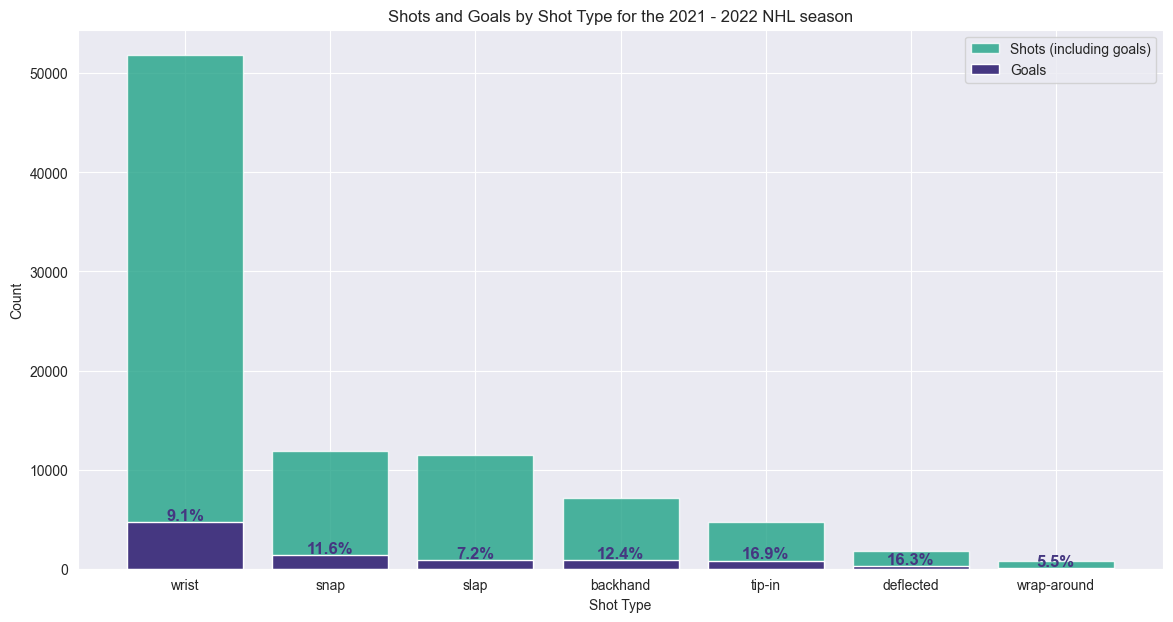

In [29]:
plot_shot_types_vs_goals(full_df, 2021)

In [30]:
import numpy as np

def compute_distance_to_net(df):
    
    """
    Calculates the distance of each shot event to the attacking net.

    This function computes the Euclidean distance in feet from the (x, y)
    coordinates of an event to the location of the net being attacked. It
    determines the target net's location (either at x=89 or x=-89) based on
    the 'attackingDirection' column for each event.

    Args:
        df (pd.DataFrame): The input DataFrame containing shot events. It must
                           include the columns: 'x', 'y', 'periodNumber',
                           'teamSide', 'gameId', and 'attackingDirection'.

    Returns:
        pd.DataFrame: A copy of the input DataFrame with a new column,
                      'distanceToNet', representing the calculated distance
                      in feet, rounded to two decimal places.

    Raises:
        ValueError: If any of the required columns are missing from the input
                    DataFrame.
    """

    required_cols = {"x", "y", "periodNumber", "teamSide", "gameId", "attackingDirection"}
    if not required_cols.issubset(df.columns):
        missing = required_cols - set(df.columns)
        raise ValueError(f"Missing required columns to calculate the distance to net: {missing}")

    df = df.copy()
    right_net_x, left_net_x = 89, -89  
    
    # If attacking -->, target is the right net (+89, 0)
    # If attacking <--, target is the left net (-89, 0)
    df["target_x"] = np.where(df['attackingDirection'] == "right", right_net_x, left_net_x)
    
    df["distanceToNet"] = np.sqrt((df["x"] - df["target_x"]) ** 2 + df["y"] ** 2).round(2)

    df = df.drop(columns=["target_x"])
    return df


In [31]:
df = compute_distance_to_net(full_df)
df

,gameId,timeInPeriod,periodNumber,teamName,teamSide,play,x,y,shootingPlayer,goalieInNet,shotType,emptyNet,strengthDuringPlay,attackingDirection,distanceToNet
0,2016020001,01:11,1,TOR,away,shot-on-goal,-77.0,5.0,Mitch Marner,Craig Anderson,wrist,False,Even (5v5),left,13.00
1,2016020001,02:53,1,OTT,home,shot-on-goal,86.0,13.0,Chris Kelly,Frederik Andersen,wrist,False,Even (5v5),right,13.34
2,2016020001,04:01,1,OTT,home,shot-on-goal,23.0,-38.0,Cody Ceci,Frederik Andersen,wrist,False,Even (5v5),right,76.16
3,2016020001,04:46,1,OTT,home,shot-on-goal,33.0,-15.0,Erik Karlsson,Frederik Andersen,slap,False,Even (5v5),right,57.97
4,2016020001,06:46,1,TOR,away,shot-on-goal,-34.0,28.0,Martin Marincin,Craig Anderson,wrist,False,Even (5v5),left,61.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
649662,2023030417,12:57,3,EDM,away,shot-on-goal,85.0,1.0,Zach Hyman,Sergei Bobrovsky,poke,False,Even (5v5),right,4.12
649663,2023030417,14:25,3,FLA,home,shot-on-goal,-52.0,-27.0,Vladimir Tarasenko,Stuart Skinner,wrist,False,Even (5v5),left,45.80
649664,2023030417,15:23,3,FLA,home,shot-on-goal,-59.0,-29.0,Aleksander Barkov,Stuart Skinner,snap,False,Even (5v5),left,41.73
649665,2023030417,15:48,3,EDM,away,shot-on-goal,57.0,-26.0,Darnell Nurse,Sergei Bobrovsky,wrist,False,Even (5v5),right,41.23


In [32]:
df.to_csv('q5_cleaned_data.csv', index=False)

PermissionError: [Errno 13] Permission denied: 'q5_cleaned_data.csv'

In [19]:
def plot_distance_vs_goal_probability(df: pd.DataFrame, seasons: list[int]) -> None:
    # Plot on a line graph the percentage of successful shots based on their distance from the goal for several seasons.
    BIN_SIZE = 5
    HALF_LENGTH_RINK = 100
    
    df['season'] = df['gameId'].astype(str).str[:4].astype(int)
    df_seasons = df[df["season"].isin(seasons)].copy()
    df_seasons['isGoal'] = (df_seasons['play'] == 'goal').astype(int)
    bins = np.arange(0, HALF_LENGTH_RINK, BIN_SIZE)
    df_seasons["distance_bin"] = pd.cut(df_seasons["distanceToNet"], bins)
    
    prob_df = (df_seasons.groupby(["season", "distance_bin"], observed=True)
               .agg(goals=('isGoal', 'sum'),
                    total_shots=('isGoal', 'count'))
               .reset_index())
    prob_df['goal_percentage'] = (prob_df['goals'] / prob_df['total_shots']) * 100
    prob_df["distance_mid"] = prob_df["distance_bin"].apply(lambda x: x.mid)
    
    season_totals = df_seasons.groupby('season').size().to_dict()
    
    plt.figure(figsize=(14, 7))
    colors = plt.cm.viridis(np.linspace(0, 1, len(seasons)))
    markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'X', '+', 'x', '|', '_']
    
    for i, season in enumerate(seasons):
        season_df = prob_df[prob_df["season"] == season].sort_values("distance_mid")
        total_shots = season_totals[season]
        
        plt.plot(
            season_df["distance_mid"],
            season_df["goal_percentage"],
            marker=markers[i],
            linewidth=2.5,
            markersize=8,
            label=f"Season {season}-{str(season+1)[-2:]} (n={total_shots:,})",
            color=colors[i]
        )
    
    plt.xlabel("Distance of shot to the net (feet)")
    plt.ylabel("Conversion rate(%)")
    plt.title("Conversion rate of shots based on the distance to the net for the 2018-2021 seasons")
    plt.legend(loc='best')
    plt.grid(True)
    plt.xticks(np.arange(0, 100, 5))
    plt.tight_layout()
    plt.show()


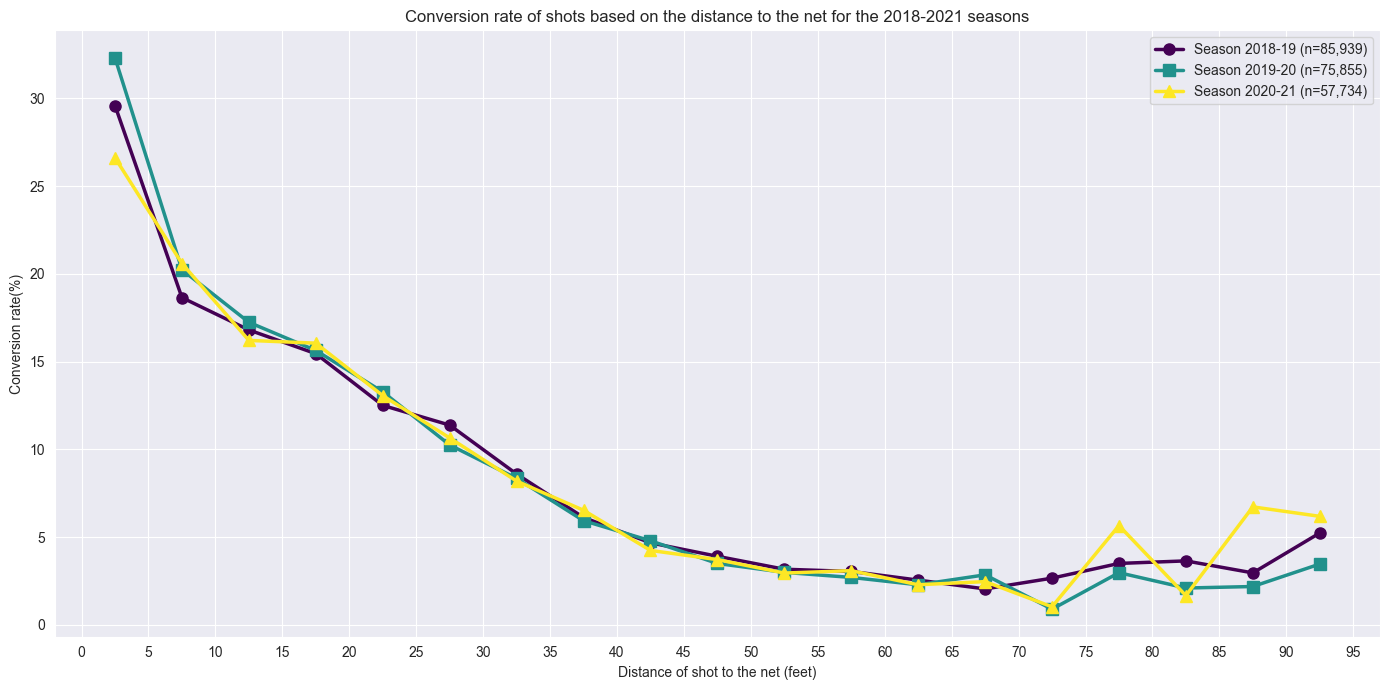

In [20]:
plot_distance_vs_goal_probability(df, [2018, 2019, 2020])

In [21]:
def plot_goal_percentage_by_distance_and_type(df: pd.DataFrame, year: int) -> None:
    # Generates a multi-line graph comparing the success rate of each type of shot based on its distance from the goal for 2019-2020 season.
    BIN_SIZE = 3
    HALF_LENGTH_RINK = 100
    
    df['season'] = df['gameId'].astype(str).str[:4].astype(int)
    season_df = df[df['season'] == year].copy()
    
    season_df['isGoal'] = (season_df['play'] == 'goal').astype(int)
    bins = np.arange(0, HALF_LENGTH_RINK + BIN_SIZE, BIN_SIZE)
    season_df["distance_bin"] = pd.cut(season_df["distanceToNet"], bins, include_lowest=True)
    
    prob_by_type_distance = (season_df.groupby(['shotType', 'distance_bin'], observed=True)
                             .agg(goals=('isGoal', 'sum'),
                                  total_shots=('isGoal', 'count'))
                             .reset_index())
    
    prob_by_type_distance['goal_percentage'] = (prob_by_type_distance['goals'] / prob_by_type_distance['total_shots'] * 100)
    prob_by_type_distance['distance_mid'] = prob_by_type_distance['distance_bin'].apply(lambda x: x.mid)
    
    prob_by_type_distance = prob_by_type_distance[prob_by_type_distance['total_shots'] >= 20]
    shot_types = prob_by_type_distance['shotType'].unique()
    shot_type_totals = season_df.groupby('shotType').size().to_dict()
    
    plt.figure(figsize=(14, 7))
    colors = plt.cm.viridis(np.linspace(0, 1, len(shot_types)))
    markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'X', '+', 'x', '|', '_']
    
    for i, shot_type in enumerate(shot_types):
        type_df = prob_by_type_distance[prob_by_type_distance['shotType'] == shot_type].sort_values('distance_mid')
        total_shots = shot_type_totals[shot_type]
        
        plt.plot(
            type_df['distance_mid'],
            type_df['goal_percentage'],
            marker=markers[i % len(markers)],
            label=f"{shot_type} (n={total_shots})",
            color=colors[i]
        )
    
    plt.xlabel("Distance between the shot and the net (feet)")
    plt.ylabel("Conversion rate (%)")
    plt.title(f"Conversion rate based on the shot type and the distance from the net for the {year}-{year+1} seasons")
    plt.legend(title="Type of shot")
    plt.grid(True)
    plt.xticks(np.arange(0, 105, 5))
    plt.ylim(0, max(prob_by_type_distance['goal_percentage']) + 5)
    plt.tight_layout()
    plt.show()

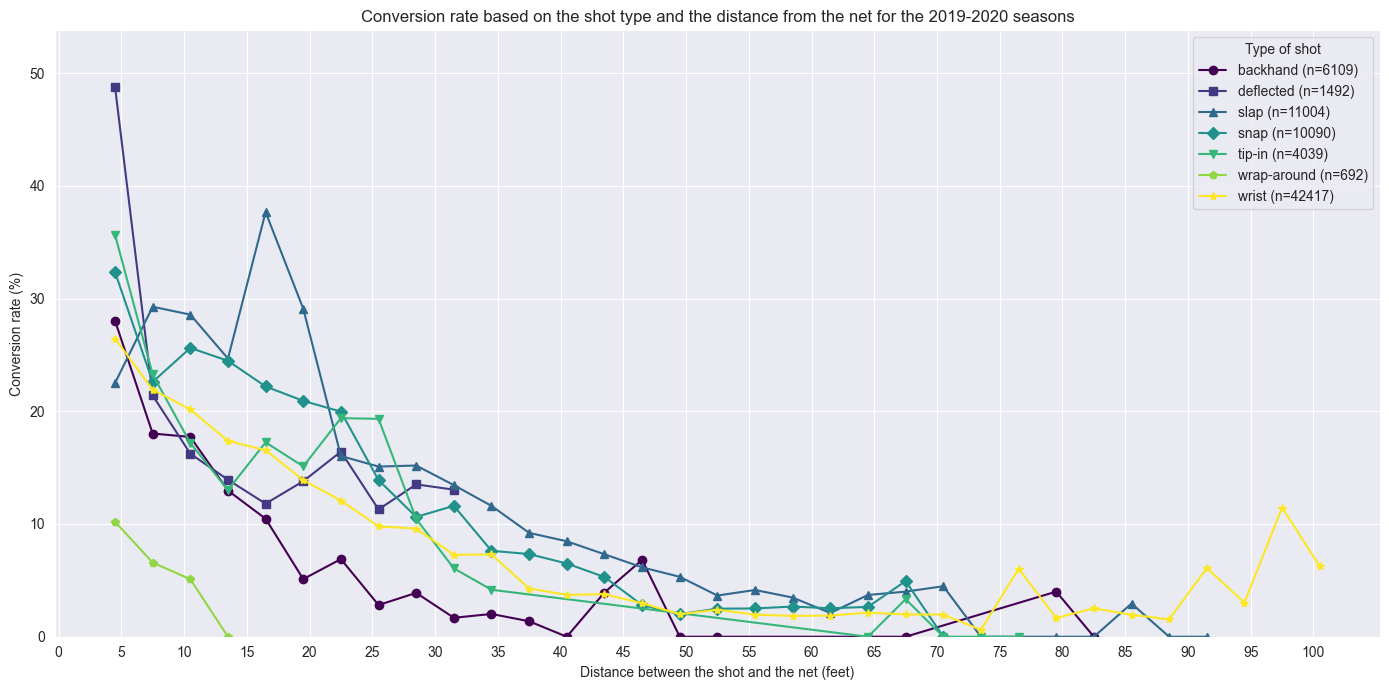

In [22]:
plot_goal_percentage_by_distance_and_type(df, 2019)